In [7]:
# ── Importaciones ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
import sys
sys.path.append(r'C:\customer360\src')
from config import DB_CONFIG

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, RocCurveDisplay)
from sqlalchemy import create_engine

# Configuración
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

engine = create_engine(
    f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@"
    f"{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
)

print("Librerías y conexión listas")

Librerías y conexión listas


In [8]:
# ── Datos para Modelo 1: Segmentación RFM ────────────────────

# Cargar transacciones con fecha real
df_txn = pd.read_sql("""
    SELECT 
        t.cliente_sk,
        f.fecha,
        t.monto,
        t.transaccion_id
    FROM dw.fact_transacciones t 
    JOIN dw.dim_fecha f ON f.fecha_sk = t.fecha_sk
""", engine)

# Cargar clientes
df_cli = pd.read_sql("""
    SELECT cliente_sk, nombre_completo, ciudad, 
           ingreso_mensual, antiguedad_meses
    FROM dw.dim_cliente
""", engine)

# Calcular variables RFM
hoy = pd.Timestamp.today()

df_rfm = df_txn.groupby('cliente_sk').agg(
    recencia        =('fecha', lambda x: (hoy - pd.to_datetime(x.max())).days),
    frecuencia      =('transaccion_id', 'count'),
    monto_total     =('monto', 'sum')
).reset_index()

print("=== Variables RFM ===")
print(df_rfm.describe())
print(f"\nClientes con RFM: {len(df_rfm):,}")

=== Variables RFM ===
       cliente_sk  recencia  frecuencia  monto_total
count     4868.00   4868.00     4868.00      4868.00
mean      2502.40     46.19       30.45     20582.19
std       1443.67     41.92       14.41     13153.62
min          1.00     21.00        6.00      1616.24
25%       1250.75     23.00       19.00     10830.66
50%       2504.50     31.00       26.00     17237.04
75%       3752.25     51.00       40.00     27007.63
max       5000.00    756.00       83.00    114642.17

Clientes con RFM: 4,868


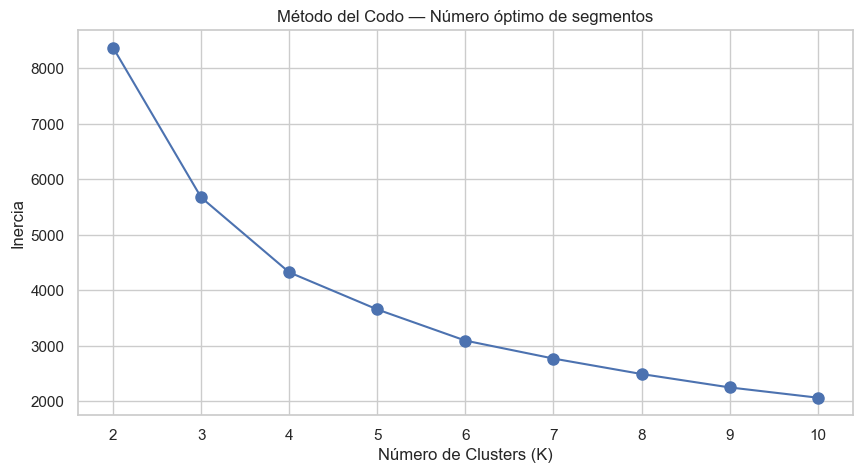

In [9]:
# ── Modelo 1: K-Means Segmentación RFM ───────────────────────

# Escalar las variables RFM
scaler = StandardScaler()
rfm_escalado = scaler.fit_transform(df_rfm[['recencia', 'frecuencia', 'monto_total']])

# Encontrar el número óptimo de clusters con el método del codo
inercias = []
K = range(2, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_escalado)
    inercias.append(km.inertia_)

# Gráfico del codo
plt.figure(figsize=(10, 5))
plt.plot(K, inercias, 'bo-', markersize=8)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del Codo — Número óptimo de segmentos')
plt.xticks(K)
plt.grid(True)
plt.savefig(r'C:\customer360\images\ml_metodo_codo.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ── Entrenar K-Means con K=4 ──────────────────────────────────
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_rfm['cluster'] = km_final.fit_predict(rfm_escalado)

# Caracterizar cada segmento
df_segmentos = df_rfm.groupby('cluster').agg(
    total_clientes  =('cliente_sk', 'count'),
    recencia_promedio=('recencia', 'mean'),
    frecuencia_promedio=('frecuencia', 'mean'),
    monto_promedio  =('monto_total', 'mean')
).round(2).reset_index()

print("=== Caracterización de Segmentos ===")
print(df_segmentos)

# Asignar nombres a los segmentos
def nombrar_segmento(row):
    if row['frecuencia_promedio'] >= 50:
        return 'Campeones'
    elif row['monto_promedio'] >= 20000:
        return 'Clientes Leales'
    elif row['recencia_promedio'] >= 100:
        return 'En Riesgo'
    else:
        return 'Clientes Regulares'

df_segmentos['segmento'] = df_segmentos.apply(nombrar_segmento, axis=1)
print("\n=== Segmentos con nombres ===")
print(df_segmentos)

# Mapear segmento a cada cliente
mapa_segmento = df_segmentos.set_index('cluster')['segmento'].to_dict()
df_rfm['segmento_rfm'] = df_rfm['cluster'].map(mapa_segmento)

print("\n=== Distribución de segmentos ===")
print(df_rfm['segmento_rfm'].value_counts())


=== Caracterización de Segmentos ===
   cluster  total_clientes  recencia_promedio  frecuencia_promedio  \
0        0            1589              34.27                37.73   
1        1            2164              39.76                19.35   
2        2             397             156.47                19.40   
3        3             718              30.97                53.87   

   monto_promedio  
0        24291.69  
1        11690.77  
2        12755.69  
3        43498.27  

=== Segmentos con nombres ===
   cluster  total_clientes  recencia_promedio  frecuencia_promedio  \
0        0            1589              34.27                37.73   
1        1            2164              39.76                19.35   
2        2             397             156.47                19.40   
3        3             718              30.97                53.87   

   monto_promedio            segmento  
0        24291.69     Clientes Leales  
1        11690.77  Clientes Regulares  
2        1

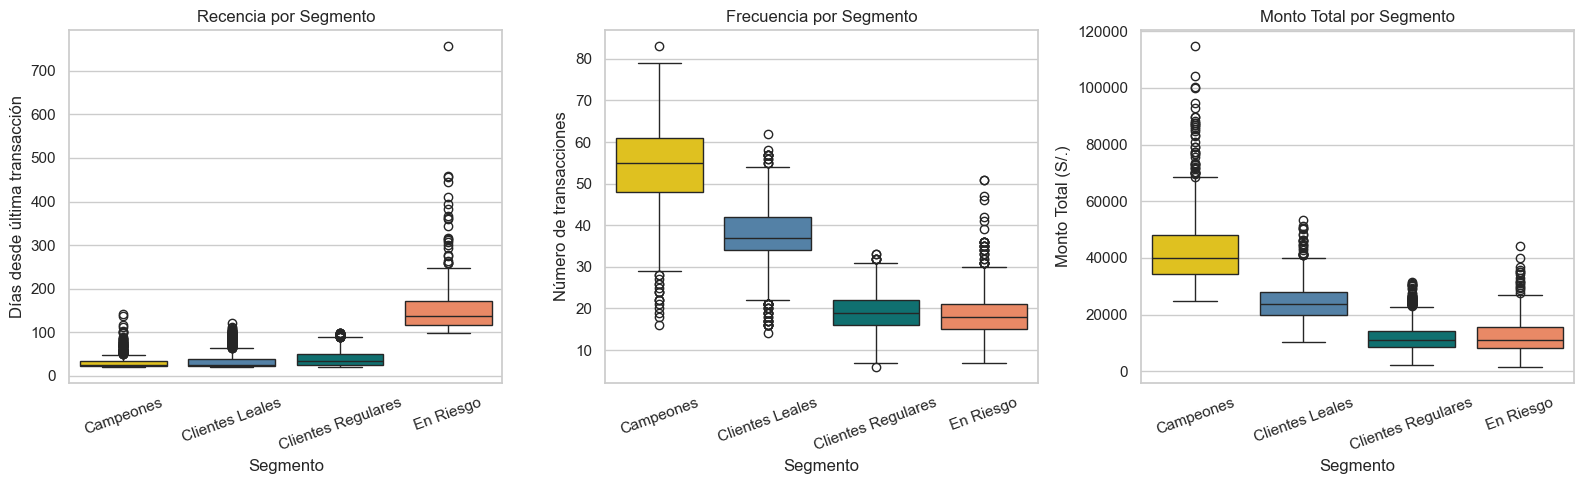

In [16]:
# ── Boxplot de segmentos RFM ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

orden = ['Campeones', 'Clientes Leales', 'Clientes Regulares', 'En Riesgo']
palette = {
    'Campeones': 'gold',
    'Clientes Leales': 'steelblue',
    'Clientes Regulares': 'teal',
    'En Riesgo': 'coral'
}

# Recencia
sns.boxplot(data=df_rfm, x='segmento_rfm', y='recencia',
            order=orden, hue='segmento_rfm', palette=palette,
            legend=False, ax=axes[0])
axes[0].set_title('Recencia por Segmento')
axes[0].set_xlabel('Segmento')
axes[0].set_ylabel('Días desde última transacción')
axes[0].tick_params(axis='x', rotation=20)

# Frecuencia
sns.boxplot(data=df_rfm, x='segmento_rfm', y='frecuencia',
            order=orden, hue='segmento_rfm', palette=palette,
            legend=False, ax=axes[1])
axes[1].set_title('Frecuencia por Segmento')
axes[1].set_xlabel('Segmento')
axes[1].set_ylabel('Número de transacciones')
axes[1].tick_params(axis='x', rotation=20)

# Monto
sns.boxplot(data=df_rfm, x='segmento_rfm', y='monto_total',
            order=orden, hue='segmento_rfm', palette=palette,
            legend=False, ax=axes[2])
axes[2].set_title('Monto Total por Segmento')
axes[2].set_xlabel('Segmento')
axes[2].set_ylabel('Monto Total (S/.)')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(r'C:\customer360\images\ml_boxplot_rfm.png', dpi=150, bbox_inches='tight')
plt.show()



In [18]:
# ── Guardar segmento_rfm en dim_cliente ───────────────────────
conn = psycopg2.connect(**DB_CONFIG)
cursor = conn.cursor()

actualizaciones = [
    (row['segmento_rfm'], int(row['cliente_sk']))
    for _, row in df_rfm.iterrows()
]

cursor.executemany("""
    UPDATE dw.dim_cliente
    SET segmento_rfm = %s
    WHERE cliente_sk = %s
""", actualizaciones)

conn.commit()

cursor.execute("SELECT segmento_rfm, COUNT(*) FROM dw.dim_cliente GROUP BY segmento_rfm")
print("=== Segmentos guardados en dim_cliente ===")
for row in cursor.fetchall():
    print(f" {str(row[0]):<20} {row[1]:>6,} clientes")

cursor.close()
conn.close()

=== Segmentos guardados en dim_cliente ===
 Campeones               718 clientes
 En Riesgo               397 clientes
 Clientes Leales       1,589 clientes
 Clientes Regulares    2,164 clientes
 None                    132 clientes


In [19]:
# ── Modelo 2: Riesgo Crediticio ───────────────────────────────

# Cargar datos de préstamos con variables del cliente
df_riesgo = pd.read_sql("""
    SELECT
        p.prestamo_id,
        p.monto,
        p.tasa_interes,
        p.plazo_meses,
        p.max_dias_mora,
        p.es_default,
        p.margen_estimado,
        c.edad,
        c.ingreso_mensual,
        c.antiguedad_meses,
        c.segmento_rfm
    FROM dw.fact_prestamos p
    JOIN dw.dim_cliente c ON c.cliente_sk = p.cliente_sk
""", engine)

# Verificar
print("=== Datos de Riesgo ===")
print(f"Total préstamos: {len(df_riesgo):,}")
print(f"\nValores nulos:")
print(df_riesgo.isnull().sum())
print(f"\nDistribución de default:")
print(df_riesgo['es_default'].value_counts())

=== Datos de Riesgo ===
Total préstamos: 4,456

Valores nulos:
prestamo_id           0
monto                 0
tasa_interes          0
plazo_meses           0
max_dias_mora         0
es_default            0
margen_estimado       0
edad                  0
ingreso_mensual       0
antiguedad_meses      0
segmento_rfm        123
dtype: int64

Distribución de default:
es_default
True     2413
False    2043
Name: count, dtype: int64


In [20]:
# ── Preparar datos para el modelo 2 ────────────────────────────

# Convertir segmento_rfm a variable numérica
df_riesgo['segmento_rfm'] = df_riesgo['segmento_rfm'].fillna('Sin Segmento')

mapa_segmento = {
    'Campeones':         4,
    'Clientes Leales':   3,
    'Clientes Regulares':2,
    'En Riesgo':         1,
    'Sin Segmento':      0
}
df_riesgo['segmento_num'] = df_riesgo['segmento_rfm'].map(mapa_segmento)

# Variables predictoras y variable objetivo
X = df_riesgo[['monto', 'tasa_interes', 'plazo_meses',
               'edad', 'ingreso_mensual', 'antiguedad_meses',
               'segmento_num']]
y = df_riesgo['es_default']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalar variables
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Entrenamiento: {len(X_train):,} registros")
print(f"Prueba:        {len(X_test):,} registros")
print(f"\nDistribución en entrenamiento:")
print(y_train.value_counts())

Entrenamiento: 3,564 registros
Prueba:        892 registros

Distribución en entrenamiento:
es_default
True     1930
False    1634
Name: count, dtype: int64


In [21]:
# ── Entrenar Regresión Logística y Random Forest ──────────────

# Regresión Logística
rl = LogisticRegression(random_state=42, max_iter=1000)
rl.fit(X_train_sc, y_train)
y_pred_rl = rl.predict(X_test_sc)
y_prob_rl = rl.predict_proba(X_test_sc)[:,1]

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

# Resultados
print("=== Regresión Logística ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rl):.4f}")
print(classification_report(y_test, y_pred_rl))

print("=== Random Forest ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

=== Regresión Logística ===
ROC-AUC: 0.6721
              precision    recall  f1-score   support

       False       0.61      0.56      0.58       409
        True       0.65      0.70      0.68       483

    accuracy                           0.64       892
   macro avg       0.63      0.63      0.63       892
weighted avg       0.63      0.64      0.63       892

=== Random Forest ===
ROC-AUC: 0.6487
              precision    recall  f1-score   support

       False       0.58      0.50      0.54       409
        True       0.62      0.70      0.66       483

    accuracy                           0.61       892
   macro avg       0.60      0.60      0.60       892
weighted avg       0.60      0.61      0.60       892



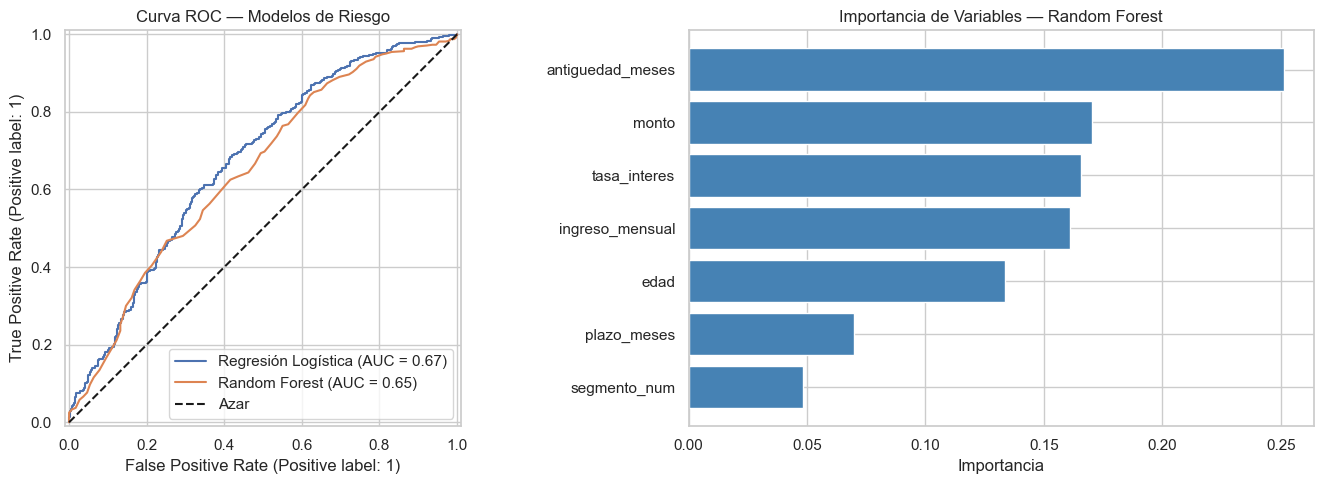

In [22]:
# ── Modelo 2: Visualización de modelos ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
RocCurveDisplay.from_predictions(
    y_test, y_prob_rl, name='Regresión Logística', ax=axes[0])
RocCurveDisplay.from_predictions(
    y_test, y_prob_rf, name='Random Forest', ax=axes[0])
axes[0].set_title('Curva ROC — Modelos de Riesgo')
axes[0].plot([0,1],[0,1],'k--', label='Azar')
axes[0].legend()

# Importancia de variables (Random Forest)
importancias = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

axes[1].barh(importancias.index, importancias.values, color='steelblue')
axes[1].set_title('Importancia de Variables — Random Forest')
axes[1].set_xlabel('Importancia')

plt.tight_layout()
plt.savefig(r'C:\customer360\images\ml_roc_riesgo.png', dpi=150, bbox_inches='tight')

plt.show()

In [23]:
# ── Calcular y guardar score_riesgo ───────────────────────────

# Calcular probabilidad de default para todos los préstamos
X_todos = df_riesgo[['monto', 'tasa_interes', 'plazo_meses',
                      'edad', 'ingreso_mensual', 'antiguedad_meses',
                      'segmento_num']]

X_todos_sc = scaler.transform(X_todos)

# Probabilidad de default (0 a 1)
prob_default = rl.predict_proba(X_todos_sc)[:,1]

# Convertir a score_riesgo (0=mayor riesgo, 100=menor riesgo)
df_riesgo['score_riesgo'] = ((1 - prob_default) * 100).round(2)

print("=== Score de Riesgo calculado ===")
print(df_riesgo['score_riesgo'].describe())

# Guardar en fact_prestamos
conn = psycopg2.connect(**DB_CONFIG)
cursor = conn.cursor()

actualizaciones = [
    (float(row['score_riesgo']), int(row['prestamo_id']))
    for _, row in df_riesgo.iterrows()
]

cursor.executemany("""
    UPDATE dw.fact_prestamos
    SET score_riesgo = %s
    WHERE prestamo_id = %s
""", actualizaciones)

conn.commit()

# Verificar
cursor.execute("""
    SELECT 
        ROUND(AVG(score_riesgo)::numeric, 2) AS score_promedio,
        ROUND(MIN(score_riesgo)::numeric, 2) AS score_minimo,
        ROUND(MAX(score_riesgo)::numeric, 2) AS score_maximo
    FROM dw.fact_prestamos
""")
row = cursor.fetchone()
print(f"\n=== Score guardado en fact_prestamos ===")
print(f"  Promedio: {row[0]}")
print(f"  Mínimo:   {row[1]}")
print(f"  Máximo:   {row[2]}")

cursor.close()
conn.close()

=== Score de Riesgo calculado ===
count   4456.00
mean      45.76
std       16.62
min       15.61
25%       31.02
50%       45.47
75%       60.46
max       77.14
Name: score_riesgo, dtype: float64

=== Score guardado en fact_prestamos ===
  Promedio: 45.76
  Mínimo:   15.61
  Máximo:   77.14


In [24]:
# ── Modelo 3: Churn ───────────────────────────────

# Cargar datos para churn
df_churn = pd.read_sql("""
    SELECT
        c.cliente_sk,
        c.edad,
        c.ingreso_mensual,
        c.antiguedad_meses,
        c.segmento_rfm,
        COUNT(DISTINCT cu.cuenta_id)           AS total_cuentas,
        MAX(CURRENT_DATE - cu.fecha_ultimo_movimiento) AS dias_inactivo,
        CASE WHEN MAX(CURRENT_DATE - cu.fecha_ultimo_movimiento) > 90
             THEN TRUE ELSE FALSE END          AS es_churn
    FROM dw.dim_cliente c
    JOIN oltp.cuenta cu ON cu.cliente_id = c.cliente_id
    GROUP BY c.cliente_sk, c.edad, c.ingreso_mensual,
             c.antiguedad_meses, c.segmento_rfm
""", engine)

# Verificar
print("=== Datos Churn ===")
print(f"Total clientes: {len(df_churn):,}")
print(f"\nDistribución de churn:")
print(df_churn['es_churn'].value_counts())
print(f"\nValores nulos:")
print(df_churn.isnull().sum())

=== Datos Churn ===
Total clientes: 5,000

Distribución de churn:
es_churn
False    2675
True     2325
Name: count, dtype: int64

Valores nulos:
cliente_sk            0
edad                  0
ingreso_mensual       0
antiguedad_meses      0
segmento_rfm        132
total_cuentas         0
dias_inactivo         0
es_churn              0
dtype: int64


In [25]:
# ── Preparar datos para el modelo 2 ────────────────────────────

# Convertir segmento_rfm a variable numérica
df_churn['segmento_rfm'] = df_churn['segmento_rfm'].fillna('Sin Segmento')

mapa_segmento = {
    'Campeones':         4,
    'Clientes Leales':   3,
    'Clientes Regulares':2,
    'En Riesgo':         1,
    'Sin Segmento':      0
}
df_churn['segmento_num'] = df_churn['segmento_rfm'].map(mapa_segmento)

# Variables predictoras y variable objetivo
X = df_X = df_churn[['edad', 'ingreso_mensual', 'antiguedad_meses',
               'segmento_num', 'total_cuentas']]
y = df_churn['es_churn']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalar variables
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Entrenamiento: {len(X_train):,} registros")
print(f"Prueba:        {len(X_test):,} registros")
print(f"\nDistribución en entrenamiento:")
print(y_train.value_counts())

Entrenamiento: 4,000 registros
Prueba:        1,000 registros

Distribución en entrenamiento:
es_churn
False    2140
True     1860
Name: count, dtype: int64


In [26]:
# ── Entrenar Random Forest ──────────────

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("=== Random Forest ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
ROC-AUC: 0.6433
              precision    recall  f1-score   support

       False       0.63      0.69      0.66       535
        True       0.60      0.53      0.56       465

    accuracy                           0.61      1000
   macro avg       0.61      0.61      0.61      1000
weighted avg       0.61      0.61      0.61      1000



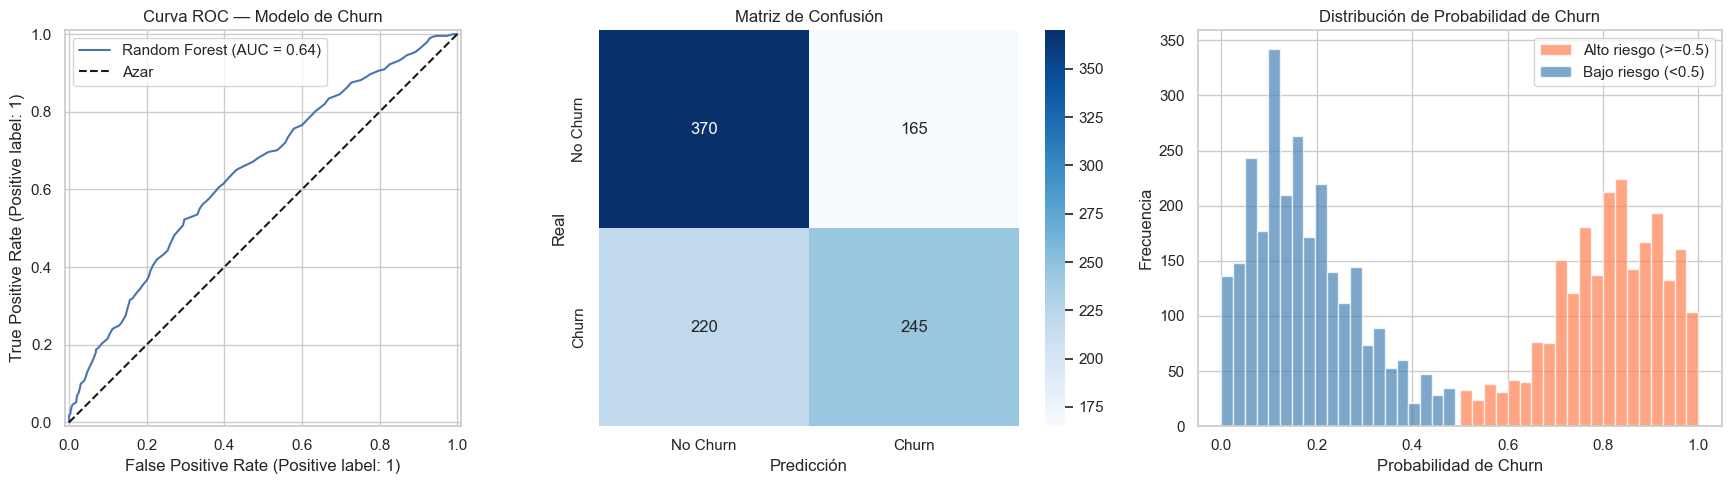

In [28]:
# ── Visualización de modelos ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Curva ROC
RocCurveDisplay.from_predictions(
    y_test, y_prob_rf, name='Random Forest', ax=axes[0])
axes[0].set_title('Curva ROC — Modelo de Churn')
axes[0].plot([0,1],[0,1],'k--', label='Azar')
axes[0].legend()

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])
axes[1].set_title('Matriz de Confusión')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

# Distribución de probabilidad de churn
# Calcular prob_churn para visualización
X_todos = df_churn[['edad', 'ingreso_mensual', 'antiguedad_meses',
                     'segmento_num', 'total_cuentas']]
prob_churn = rf.predict_proba(X_todos)[:,1]
df_churn['prob_churn'] = prob_churn.round(4)
axes[2].hist(df_churn[df_churn['prob_churn'] >= 0.5]['prob_churn'],
             bins=20, color='coral', alpha=0.7, label='Alto riesgo (>=0.5)')
axes[2].hist(df_churn[df_churn['prob_churn'] < 0.5]['prob_churn'],
             bins=20, color='steelblue', alpha=0.7, label='Bajo riesgo (<0.5)')
axes[2].set_title('Distribución de Probabilidad de Churn')
axes[2].set_xlabel('Probabilidad de Churn')
axes[2].set_ylabel('Frecuencia')
axes[2].legend()

plt.tight_layout()
plt.savefig(r'C:\customer360\images\ml_roc_churn.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# ── Calcular y guardar prob_churn en dim_cliente ──────────────

# Variables predictoras para todos los clientes
X_todos = df_churn[['edad', 'ingreso_mensual', 'antiguedad_meses',
                     'segmento_num', 'total_cuentas']]

# Probabilidad de churn (0 a 1)
prob_churn = rf.predict_proba(X_todos)[:,1]
df_churn['prob_churn'] = prob_churn.round(4)

print("=== Probabilidad de Churn calculada ===")
print(df_churn['prob_churn'].describe())

# Guardar en dim_cliente
conn = psycopg2.connect(**DB_CONFIG)
cursor = conn.cursor()

actualizaciones = [
    (float(row['prob_churn']), int(row['cliente_sk']))
    for _, row in df_churn.iterrows()
]

cursor.executemany("""
    UPDATE dw.dim_cliente
    SET prob_churn = %s
    WHERE cliente_sk = %s
""", actualizaciones)

conn.commit()

# Verificar resultados en la base de datos
cursor.execute("""
    SELECT 
        ROUND(AVG(prob_churn)::numeric, 4) AS prob_promedio,
        ROUND(MIN(prob_churn)::numeric, 4) AS prob_minimo,
        ROUND(MAX(prob_churn)::numeric, 4) AS prob_maximo
    FROM dw.dim_cliente
""")
row = cursor.fetchone()
print(f"\n=== Churn guardado en dim_cliente ===")
print(f"  Promedio: {row[0]}")
print(f"  Mínimo:   {row[1]}")
print(f"  Máximo:   {row[2]}")

cursor.close()
conn.close()

=== Probabilidad de Churn calculada ===
count   5000.00
mean       0.47
std        0.34
min        0.00
25%        0.14
50%        0.36
75%        0.81
max        1.00
Name: prob_churn, dtype: float64

=== Churn guardado en dim_cliente ===
  Promedio: 0.4654
  Mínimo:   0.0000
  Máximo:   1.0000
